[[ 1.   2.   0.   2. ]
 [ 4.   5.   0.   2. ]
 [ 0.   8.   0.1  3. ]
 [ 6.   7.   0.1  2. ]
 [ 9.  11.   0.1  4. ]
 [ 3.  12.   0.2  5. ]
 [10.  13.   0.4  8. ]]
[1 1 1 3 2 2 2 2]
[1 1 1 3 2 2 2 2]
[2 1 1 6 3 3 4 5]
[0]
[-1  1  1  6  3  3  4  5]
[0, 4]
[-1  1  1  6 -1 -1  4  5]
[0, 4, 3]
[-1  1  1 -1 -1 -1  4  5]
[0, 4, 3, 1]


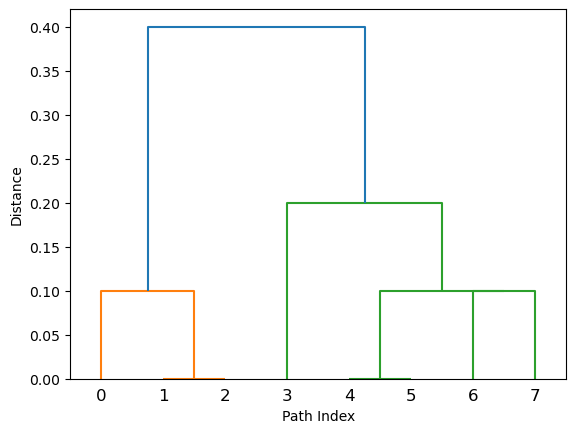

In [1]:
import copy

import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, fcluster


def calc_cluster_distnce(
    cluster1: list[int], 
    cluster2: list[int], 
    distance_matrix: np.ndarray, 
    method: str='single'
    ) -> float:
    """
    Calculate distance between two clusters using distance matrix.
    """
    if method == 'single':
        return np.min(distance_matrix[cluster1][:, cluster2])
    elif method == 'complete':
        return np.max(distance_matrix[cluster1][:, cluster2])
    elif method == 'average':
        return np.mean(distance_matrix[cluster1][:, cluster2])
    else:
        raise ValueError(f"Invalid method: {method}")


def hierarchical_clustering(distance_matrix: np.ndarray) -> np.ndarray:
    """
    Perform hierarchical clustering.

    Parameters
    ----------
    distance_matrix : np.ndarray
        Distance matrix between samples.

    Returns
    -------
    Z : np.ndarray
        Linkage matrix. Each row represents a pair of clusters to be merged.
        The first two elements are the cls_indices of clusters to be merged,
        the third element is the distance between the clusters,
        and the fourth element is the number of samples in the new cluster.
    """
    N = new_cls_idx = len(distance_matrix)
    clusters = {idx: [idx] for idx in range(N)}
    Z = np.array([], dtype=float).reshape(0, 4)

    while len(clusters) > 1:
        # 最小距離を探す
        min_dist = float('inf')
        to_merge = None

        for cls1 in clusters:
            for cls2 in clusters:
                if cls1 != cls2:
                    dist = calc_cluster_distnce(
                        clusters[cls1], clusters[cls2], distance_matrix, method='single'
                        )
                    if dist < min_dist:
                        min_dist = dist
                        to_merge = cls1, cls2

        if not to_merge:
            break

        # クラスタを結合
        cls1, cls2 = to_merge
        new_cluster = clusters[cls1] + clusters[cls2]
        # 更新
        clusters[new_cls_idx] = new_cluster
        del clusters[cls1]
        del clusters[cls2]

        # リンク情報を保存
        Z = np.vstack([Z, [cls1, cls2, min_dist, len(new_cluster)]])
        new_cls_idx += 1

    return Z


def select_paths_idx(
    Z: np.ndarray, 
    w_paths: np.ndarray, 
    num_paths: int
    ) -> list[int]:
    """
    Select a path of clusters to form a specified number of clusters.

    Parameters
    ----------
    Z : np.ndarray
        Linkage matrix.
    w_paths : np.ndarray
        List of path weights.
    num_paths : int
        Number of clusters to be selcted.

    Returns
    -------
    selected_paths : list[int]
        List of index of paths to be selected.
    """
    selected_paths = []
    # maxclustでクラスタリング
    maxclust = fcluster(Z, num_paths, criterion='maxclust')
    print(maxclust)
    # maxclustで選択されたクラスタの数とnum_pathsを比較
    if len(set(maxclust)) == num_paths:
        # 各クラスタの重みの最も小さいものを選択
        for i in range(1, num_paths+1):
            # クラスタ番号がiのパスの中で重みが最小のものを選択
            path_idxs = np.where(maxclust == i)[0]
            selected_paths.append(path_idxs[np.argmin(w_paths[path_idxs])])
    else:
        # クラスタ数がnum_pathsより多くなるまでmaxclustを増やす
        maxclust_before = copy.deepcopy(maxclust)
        count = 1
        while len(set(maxclust)) <= num_paths:
            maxclust = fcluster(Z, num_paths+count, criterion='maxclust')
            count += 1
            if num_paths + count > Z.shape[0] + 1:
                maxclust = np.array(range(Z.shape[0] + 1), dtype=float)
                break
        print(maxclust_before)
        print(maxclust)
        n_before = len(set(maxclust_before))
        n_after = len(set(maxclust))
        # maxclust_beforeとmaxclustのクラスタが同じクラスタのパスを選ぶ
        for cls in range(1, n_before+1):
            # cls_idxのクラスタの中で重みが最小のものを選択
            path_idxs = np.where(maxclust_before == cls)[0]
            w_min_path = path_idxs[np.argmin(w_paths[path_idxs])]
            selected_paths.append(w_min_path)
            # 選ばれたパスのmaxclustにおけるクラスタ番号を-1にする
            cls_after = maxclust[w_min_path]
            maxclust[maxclust == cls_after] = -1
            print(selected_paths)
            print(maxclust)

        # num_pathsの数までパスを選択
        for _ in range(num_paths - len(selected_paths)):
            w_min = float('inf')
            w_min_path = None
            selected_cls = None
            for cls in range(1, n_after+1):
                if cls not in maxclust:
                    continue
                path_idxs = np.where(maxclust == cls)[0]
                w = np.min(w_paths[path_idxs])
                if w < w_min:
                    w_min = w
                    w_min_path = path_idxs[np.argmin(w_paths[path_idxs])]
                    selected_cls = cls
            selected_paths.append(w_min_path)
            # 選ばれたクラスタ番号を-1にする
            maxclust[maxclust == selected_cls] = -1

    return selected_paths
                

# デンドログラムを描くための関数
def plot_dendrogram(Z: np.ndarray) -> None:
    dendrogram(Z)
    plt.xlabel('Path Index')
    plt.ylabel('Distance')
    plt.show()

# 同じ距離を持つクラスタを含む距離行列 D の例
D = np.array([
    [0, 6, 2, 4, 1, 7, 7, 2], 
    [6, 0, 8, 4, 7, 1, 1, 8], 
    [2, 8, 0, 4, 1, 9, 9, 0], 
    [2, 4, 4, 0, 3, 5, 5, 4], 
    [1, 7, 1, 3, 0, 8, 8, 1], 
    [7, 1, 9, 5, 8, 0, 0, 9], 
    [7, 1, 9, 5, 8, 0, 0, 9], 
    [2, 8, 0, 4, 1, 9, 9, 0]
], dtype=float)
D /= 10
D = D[[1, 5, 6, 3, 2, 7, 0, 4], :]
D = D[:, [1, 5, 6, 3, 2, 7, 0, 4]]

w_paths = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

# 階層型クラスタリングを実行
Z = hierarchical_clustering(D)
print(Z)

# パスを選択
num_paths = 4
selected_paths = select_paths_idx(Z, w_paths, num_paths)
print(selected_paths)

# デンドログラムを描画
plot_dendrogram(Z)

[[0.  1.  0.4 2. ]
 [2.  4.  0.9 3. ]
 [3.  5.  1.  4. ]]
[1 1 1 2]
[1 1 1 2]
[0. 1. 2. 3.]
[0]
[-1.  1.  2.  3.]
[0, 3]
[-1.  1.  2. -1.]
[0, 3, 1, 2]


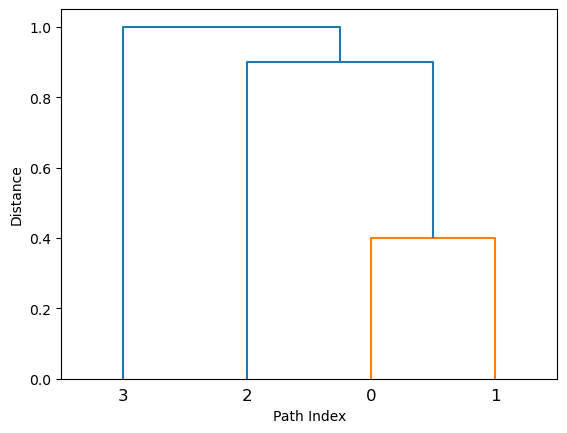

In [2]:
# 同じ距離を持つクラスタを含む距離行列 D の例
D = np.array([
    [0, 0.4, 0.9, 1.0], 
    [0.4, 0, 0.9, 1.0], 
    [0.9, 0.9, 0, 1.0], 
    [1.0, 1.0, 1.0, 0]
], dtype=float)
# D /= 10

w_paths = np.array([0.1, 0.2, 0.3, 0.4])

# 階層型クラスタリングを実行
Z = hierarchical_clustering(D)
print(Z)

# パスを選択
num_paths = 4
selected_paths = select_paths_idx(Z, w_paths, num_paths)
print(selected_paths)

# デンドログラムを描画
plot_dendrogram(Z)

[[0.         0.45266554 0.37701136 ... 0.54877887 0.0924008  0.19561912]
 [0.45266554 0.         0.92211726 ... 0.25274865 0.44787997 0.81243845]
 [0.37701136 0.92211726 0.         ... 0.50294151 0.43902481 0.53915479]
 ...
 [0.54877887 0.25274865 0.50294151 ... 0.         0.80499311 0.59901117]
 [0.0924008  0.44787997 0.43902481 ... 0.80499311 0.         0.45363523]
 [0.19561912 0.81243845 0.53915479 ... 0.59901117 0.45363523 0.        ]]
[0.85201435 0.15276749 0.80333779 0.91268568 0.13207167 0.65619209
 0.56957528 0.02428333 0.887681   0.6261839  0.25021196 0.93201044
 0.35396466 0.73024572 0.65592532 0.40118262 0.80538382 0.9085566
 0.38873042 0.5275531  0.53669028 0.48115431 0.1229032  0.51012709
 0.17834551 0.08939468 0.25816664 0.94982856 0.48919302 0.41944898
 0.71173759 0.67946222 0.81107811 0.92595753 0.38468855 0.19940416
 0.80826774 0.26744831 0.16648786 0.92774891 0.7043709  0.769752
 0.33338176 0.62556219 0.28900885 0.2213699  0.8536307  0.42874598
 0.59970748 0.23436659 

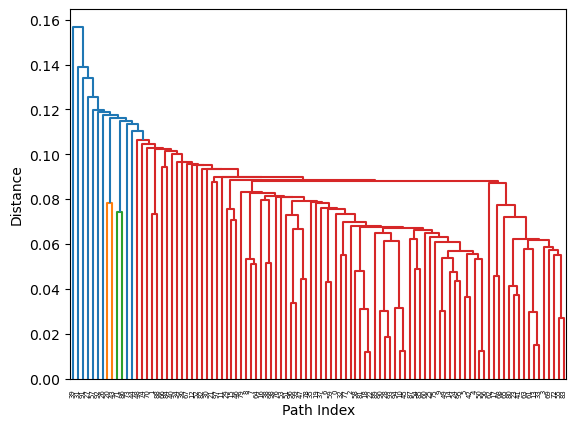

In [9]:
# 距離行列の次元
n = 100

# 40x40のランダムな距離行列を生成
D = np.random.rand(n, n)

# 対称行列に変換し、対角要素をゼロに設定
D = (D + D.T) / 2
np.fill_diagonal(D, 0)

# 長さ40のランダムな重みベクトルを生成
w_paths = np.random.rand(n)

print(D)
print(w_paths)

# 階層型クラスタリングを実行
Z = hierarchical_clustering(D)
print(Z)

# パスを選択
num_paths = 5
selected_paths = select_paths_idx(Z, w_paths, num_paths)
print(selected_paths)

# デンドログラムを描画
plot_dendrogram(Z)

[1. 2. 3.]
[1 1 1]
[ 1.  2. -1.]
[2]
[-1.  2. -1.]
[2, 0]
[-1. -1. -1.]
[2, 0, 1]


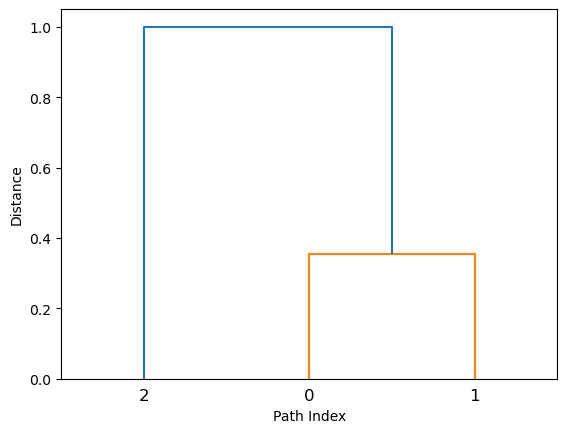

NSF 1 3
n_paths: 3
parmas: {'path_weight': 'physical-length', 'sim_weight': 'physical-length', 'cls_distance': 'single'}
selected_paths_idxs: [2, 0, 1]
[[1, 2, 3], [1, 2, 4, 5, 6, 3], [1, 3]]


[[1, 3], [1, 2, 3], [1, 2, 4, 5, 6, 3]]

In [3]:
import sys
sys.path.append('../../../')

from src.paths.algorithms.hierarchical_clustering import HierarchicalClustering

# parameters
graph_name = 'NSF'
n_path = 3
path_weights = 'physical-length'
sim_weights = 'physical-length'
cls_distances = 'single'

hierarchical_clustering_ins = HierarchicalClustering(
    graph_name, n_path, params={'path_weight': path_weights, 'sim_weight': sim_weights, 'cls_distance': cls_distances}
)
hierarchical_clustering_ins.select_k_paths_single_pair(1, 3)